# Описание датасета

В работе используется датасет Gaming and Mental Behavioral Dataset, представляющий собой синтетичекси сгенерированные данные о поведении игроков, их психическом состоянии, образе жизни и соицальной среде.

Выбор данного датасета обусловлен:
- большим объёмом данных
- наличием разнообразных признаков
- возможностью решения задачи классификации игровой зависимости

Исходный датасет содержит:
- 10000000 строк
- 40 признаков

Набор данных содержит переменные, сгруппированные в шесть основных областей.

1. Демографические характеристики
- age — Возраст участника
- gender — Категория пола
- income — Оценка ежемесячного дохода

2. Характеристики игрового поведения
- daily_gaming_hours — Среднее ежедневное время игры
- weekly_sessions — Количество игровых сессий в неделю
- years_gaming — Общее количество лет игрового опыта
- weekend_gaming_hours — Продолжительность игры в выходные
- multiplayer_ratio — Доля многопользовательской игры
- violent_games_ratio — Доля игр с насилием
- mobile_gaming_ratio — Доля мобильных игр
- night_gaming_ratio — Доля ночных игр
- competitive_rank — Соревновательный рейтинг навыков
- esports_interest — Интерес к участию в киберспорте
- streaming_hours — Еженедельное количество часов стриминга игр
- microtransactios_spending — Ежемесячные внутриигровые траты
- headset_usage — Использование гарнитуры

3. Характеристики психологического здоровья
- stress_level — Оценка воспринимаемого стресса
- anxiety_score — Оценка тревожности
- depression_score — Оценка депрессии
- addiction_level — Индикатор игровой зависимости
- loneliness_score — Индекс одиночества
- aggression_score — Оценка склонности к агрессии
- happiness_score — Общий уровень счастья

4. Характеристики социальной среды
- social_interaction_score — Индекс социальной активности
- relationship_satisfaction — Оценка качества отношений
- friends_gaming_count — Количество друзей, играющих в игры
- online_friends — Онлайн-социальные связи
- toxic_exposure — Подверженность токсичным сообществам
- parental_supervision — Оценка родительского контроля

5. Характеристики образа жизни
- sleep_hours — Средняя продолжительность сна
- exercise_hours — Еженедельное количество часов упражнений
- caffeine_intake — Ежедневное потребление кофеина
- screen_time_total — Общее ежедневное время перед экраном
- internet_quality — Качество интернет-соединения

6. Показатели физического здоровья
- bmi — Индекс массы тела
- eye_strain_score — Степень напряжения глаз
- back_pain_score — Степень боли в спине

7. Показатели продуктивности / эффективности
- academic_performance — Академическая успеваемость
- work_productivity — Продуктивность на рабочем месте

Так как исходная переменная addiction_level представлена в видде непрерывной шкалы от 0 до 10, она была преобразована в категориальный признак addiction_category (целевая переменная).

Для этого использовалось разбиение по квантилям (q=3), что похволило сформировать 3 класса: низкий, средний и высоский уровень игровой зависимости.

Такой подход обеспечивает баланс классов и повышает устойчивость модели.

In [3]:
from pathlib import Path

# корень проекта (поднимаемся на уровень выше notebooks)
BASE_DIR = Path().resolve().parent

# пути
DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"
MODELS_DIR = BASE_DIR / "models"
IMAGES_DIR = BASE_DIR / "report" / "images"

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv(DATA_RAW / "gaming_data.csv")

# создаём категориальный таргет
df['addiction_category'] = pd.qcut(
    df['addiction_level'],
    q=3,
    labels=['low', 'medium', 'high']
)

# проверяем баланс классов до сэмплирования
print("Before sampling:")
print(df['addiction_category'].value_counts(normalize=True))

# стратифицированная выборка
df_sample, _ = train_test_split(
    df,
    train_size=50000,
    stratify=df['addiction_category'],
    random_state=42
)

df = df_sample.copy()

# проверяем баланс после
print("\nAfter sampling:")
print(df['addiction_category'].value_counts(normalize=True))

Before sampling:
addiction_category
medium    0.333655
low       0.333562
high      0.332783
Name: proportion, dtype: float64

After sampling:
addiction_category
medium    0.33366
low       0.33356
high      0.33278
Name: proportion, dtype: float64


Общая информация

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 896932 to 281278
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   age                         50000 non-null  int64   
 1   gender                      50000 non-null  object  
 2   income                      50000 non-null  int64   
 3   daily_gaming_hours          50000 non-null  float64 
 4   weekly_sessions             50000 non-null  int64   
 5   years_gaming                50000 non-null  int64   
 6   sleep_hours                 50000 non-null  float64 
 7   caffeine_intake             50000 non-null  float64 
 8   exercise_hours              50000 non-null  float64 
 9   stress_level                50000 non-null  int64   
 10  anxiety_score               50000 non-null  float64 
 11  depression_score            50000 non-null  float64 
 12  social_interaction_score    50000 non-null  float64 
 13  relationship_sa

Разделение типов

In [6]:
# числовые признаки
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# категориальные признаки
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical features:")
print(num_cols)

print("\nCategorical features:")
print(cat_cols)

Numerical features:
Index(['age', 'income', 'daily_gaming_hours', 'weekly_sessions',
       'years_gaming', 'sleep_hours', 'caffeine_intake', 'exercise_hours',
       'stress_level', 'anxiety_score', 'depression_score',
       'social_interaction_score', 'relationship_satisfaction',
       'academic_performance', 'work_productivity', 'addiction_level',
       'multiplayer_ratio', 'toxic_exposure', 'violent_games_ratio',
       'mobile_gaming_ratio', 'night_gaming_ratio', 'weekend_gaming_hours',
       'friends_gaming_count', 'online_friends', 'streaming_hours',
       'esports_interest', 'headset_usage', 'microtransactions_spending',
       'parental_supervision', 'loneliness_score', 'aggression_score',
       'happiness_score', 'bmi', 'screen_time_total', 'eye_strain_score',
       'back_pain_score', 'competitive_rank', 'internet_quality'],
      dtype='object')

Categorical features:
Index(['gender', 'addiction_category'], dtype='object')


Бинарные признаки

In [7]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

print("\nБинарные признаки:")
print(binary_cols)


Бинарные признаки:
['headset_usage']


In [8]:
df.describe()

,age,income,daily_gaming_hours,weekly_sessions,years_gaming,sleep_hours,caffeine_intake,exercise_hours,stress_level,anxiety_score,...,parental_supervision,loneliness_score,aggression_score,happiness_score,bmi,screen_time_total,eye_strain_score,back_pain_score,competitive_rank,internet_quality
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,35.969860,78004.944640,3.997298,20.130000,12.020640,7.006017,1.995442,2.002743,5.509320,4.993796,...,5.031240,5.012556,5.009905,5.984031,24.012296,8.003967,5.005440,4.009947,49.356660,5.502320
std,13.569834,41740.833397,2.825910,11.272336,7.221577,1.499408,1.997907,1.993824,2.868846,1.989024,...,3.155817,1.990245,1.972073,1.964596,3.999401,4.028967,1.978197,1.950940,28.854504,2.870596
min,13.000000,5004.000000,0.010000,1.000000,0.000000,1.010000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,7.320000,0.250000,0.000000,0.000000,0.000000,1.000000
25%,24.000000,42090.750000,1.920000,10.000000,6.000000,6.000000,0.580000,0.580000,3.000000,3.640000,...,2.000000,3.650000,3.650000,4.650000,21.300000,5.060000,3.660000,2.660000,24.000000,3.000000
50%,36.000000,78296.500000,3.350000,20.000000,12.000000,7.010000,1.380000,1.390000,6.000000,4.990000,...,5.000000,5.010000,5.010000,6.010000,24.020000,7.340000,5.010000,3.990000,50.000000,6.000000
75%,48.000000,114309.250000,5.380000,30.000000,18.000000,8.020000,2.760000,2.790000,8.000000,6.360000,...,8.000000,6.370000,6.350000,7.350000,26.690000,10.222500,6.340000,5.350000,74.000000,8.000000
max,59.000000,149993.000000,25.340000,39.000000,24.000000,13.180000,22.830000,24.380000,10.000000,10.000000,...,10.000000,10.000000,10.000000,10.000000,39.790000,41.480000,10.000000,10.000000,99.000000,10.000000


# Полная очистка

Пропуски

In [9]:
# количество пропусков по каждому столбцу
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


Удаление дубликатов

In [10]:
print("До:", df.shape)

df = df.drop_duplicates()

print("После:", df.shape)

До: (50000, 40)


После: (50000, 40)


Приведение типов даных

In [11]:
# категориальные
df['gender'] = df['gender'].astype('category')

# бинарные
binary_cols = [col for col in df.columns if df[col].nunique() == 2]

for col in binary_cols:
    df[col] = df[col].astype('category')

Выбросы (IQR)

In [12]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[col] >= lower) & (df[col] <= upper)]

In [13]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    df = remove_outliers(df, col)

Работа с фичами: исходное количество, новые фичи, feature engineering

Исходное количество

In [14]:
print("Total features:", df.shape[1])
print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Total features: 40
Numerical: 38
Categorical: 2


future engineering

In [15]:
# недельная игровая нагрузка (общее игровое время за неделю)
df['total_gaming_load'] = df['daily_gaming_hours'] * 5 + df['weekend_gaming_hours']

In [16]:
# интенсивность игрового поведения (частота * длительность = вовлеченность)
df['gaming_intensity'] = df['weekly_sessions'] * df['daily_gaming_hours']


In [17]:
# восстановление организма
df['recovery_score'] = df['sleep_hours'] + df['exercise_hours']

In [18]:
# физическая нагрузка
df['physical_strain'] = df['eye_strain_score'] + df['back_pain_score']

In [19]:
# средний уровень продуктивности
df['productivity_index'] = (
    df['academic_performance'] +
    df['work_productivity']
) / 2

 data leakage

Для предотвращения утечки данных были исключены признаки, напрямую описывающие уровень игровой зависимоти, а не ее причины.

In [20]:
cols = [
    'addiction_level',
    'stress_level',
    'anxiety_score',
    'depression_score',
    'loneliness_score',
    'happiness_score',
    'aggression_score'
]

In [21]:
df = df.drop(columns=cols)

Итоговое количество признаков

In [22]:
# числовые признаки
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# категориальные признаки
cat_cols = df.select_dtypes(include=['object', 'category']).columns

print("Total features:", df.shape[1])
print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Total features: 38
Numerical: 35
Categorical: 3


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36763 entries, 896932 to 281278
Data columns (total 38 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   age                         36763 non-null  int64   
 1   gender                      36763 non-null  category
 2   income                      36763 non-null  int64   
 3   daily_gaming_hours          36763 non-null  float64 
 4   weekly_sessions             36763 non-null  int64   
 5   years_gaming                36763 non-null  int64   
 6   sleep_hours                 36763 non-null  float64 
 7   caffeine_intake             36763 non-null  float64 
 8   exercise_hours              36763 non-null  float64 
 9   social_interaction_score    36763 non-null  float64 
 10  relationship_satisfaction   36763 non-null  float64 
 11  academic_performance        36763 non-null  float64 
 12  work_productivity           36763 non-null  float64 
 13  multiplayer_rat

In [24]:
df.to_csv(DATA_PROCESSED / "cleaned.csv", index=False)

# Визуализации, графики, отражающие зависимости

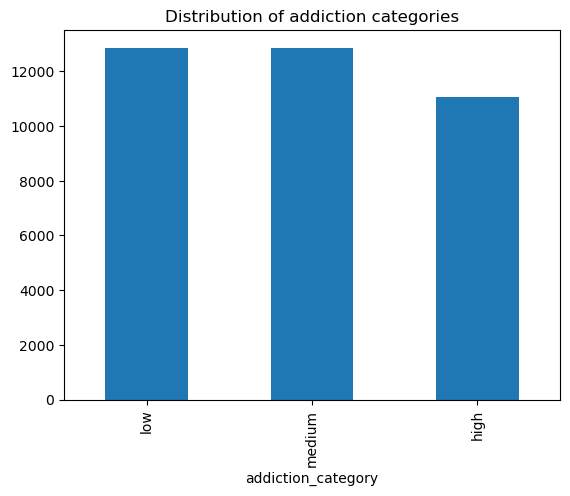

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

df['addiction_category'].value_counts().plot(kind='bar')
plt.title("Distribution of addiction categories")
plt.show()

Распределение целевой переменной показывает умеренный баланс классов, что позволяет обучать модель без дополнительного ресэмплинга.

Игровая нагрузка vs зависимость

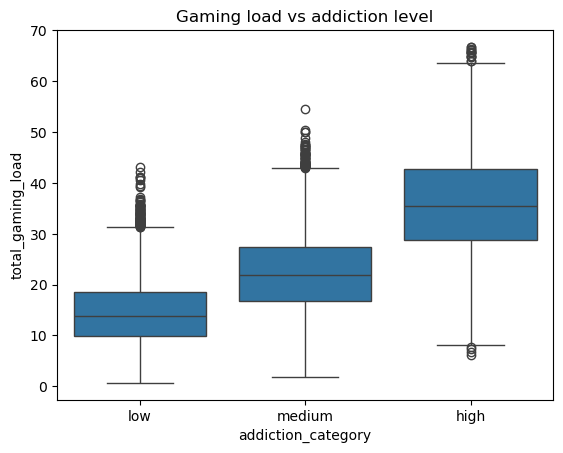

In [26]:
sns.boxplot(data=df, x='addiction_category', y='total_gaming_load')
plt.title("Gaming load vs addiction level")
plt.show()

Цифровая перегрузка vs зависимость

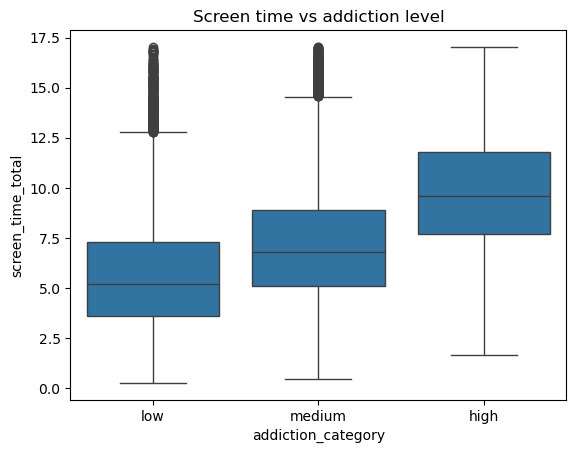

In [27]:
sns.boxplot(data=df, x='addiction_category', y='screen_time_total')
plt.title("Screen time vs addiction level")
plt.show()

Сон vs зависимость

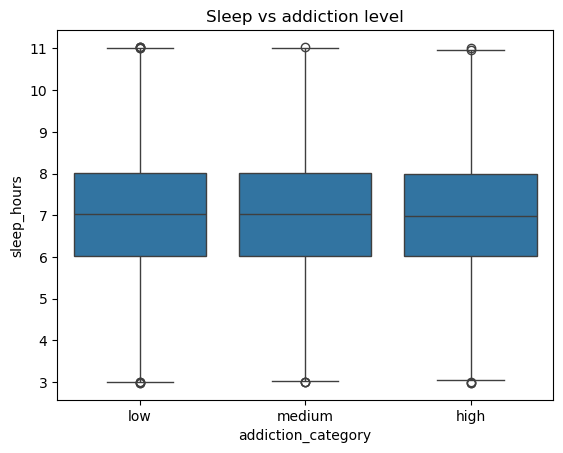

In [28]:
sns.boxplot(data=df, x='addiction_category', y='sleep_hours')
plt.title("Sleep vs addiction level")
plt.show()

Продуктивность vs зависимость

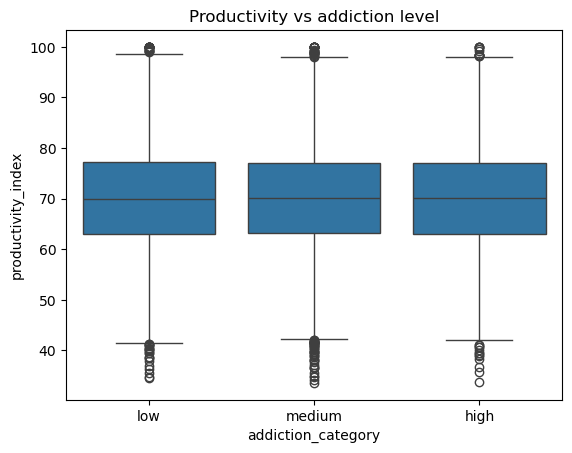

In [29]:
sns.boxplot(data=df, x='addiction_category', y='productivity_index')
plt.title("Productivity vs addiction level")
plt.show()

Корреляционная матрица

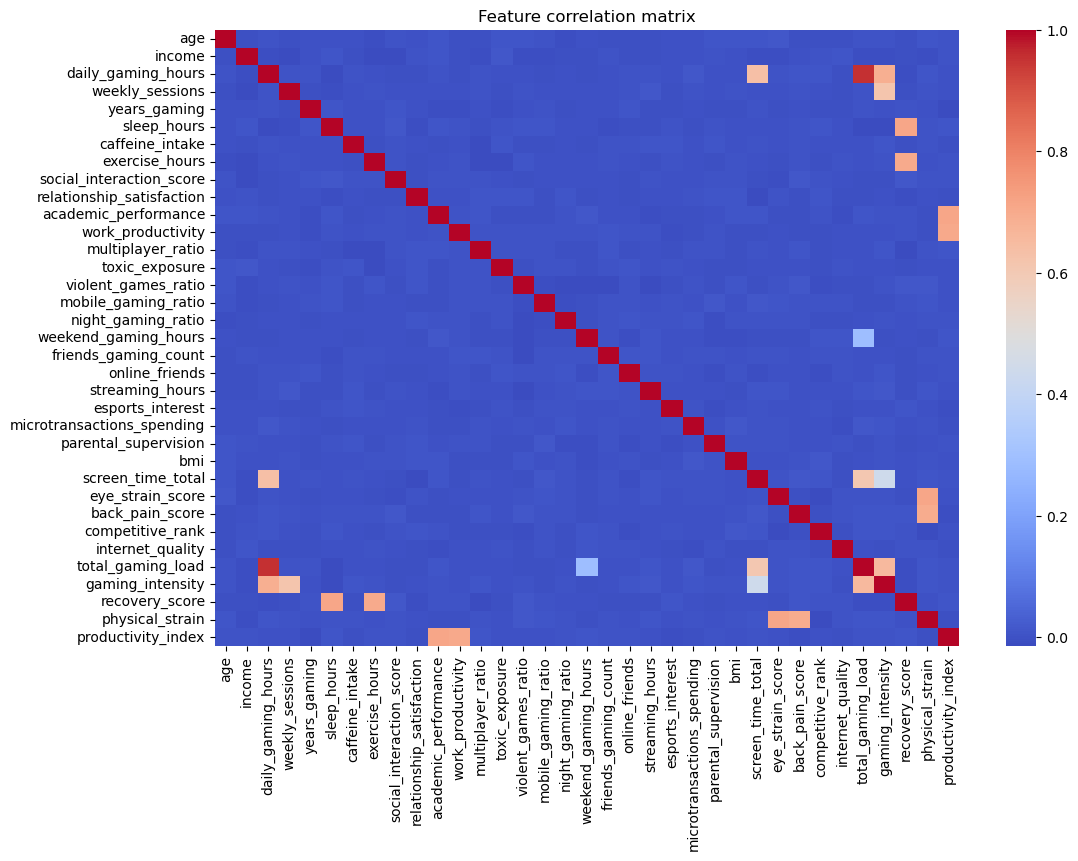

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Feature correlation matrix")
plt.show()

Социальная активность vs зависимость

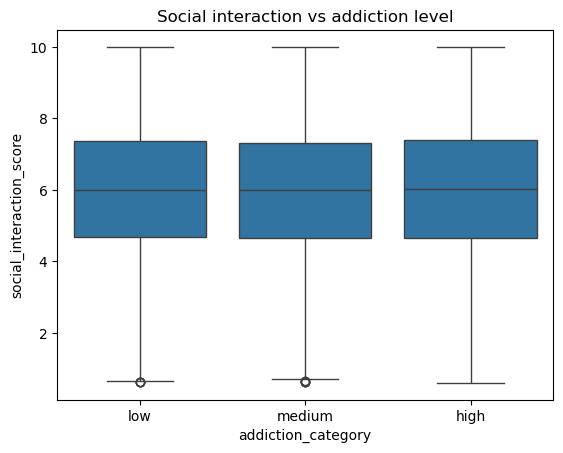

In [31]:
sns.boxplot(data=df, x='addiction_category', y='social_interaction_score')
plt.title("Social interaction vs addiction level")
plt.show()

Физическое состояние vs зависимость

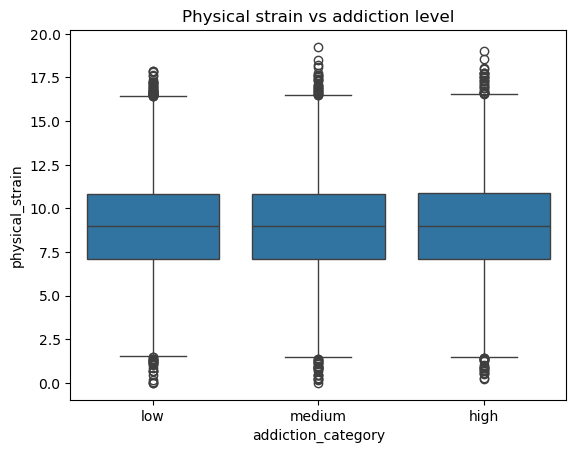

In [32]:
sns.boxplot(data=df, x='addiction_category', y='physical_strain')
plt.title("Physical strain vs addiction level")
plt.show()

Гистограмма игровых часов

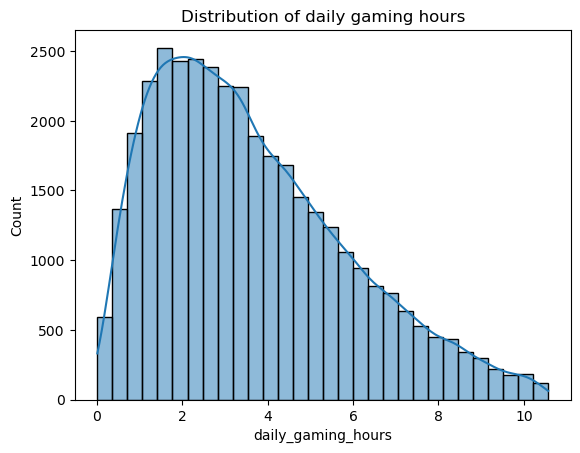

In [33]:
sns.histplot(df['daily_gaming_hours'], bins=30, kde=True)
plt.title("Distribution of daily gaming hours")
plt.show()

В рамках анализа данных были построены визуализации, отражающие зависимости между поведенческими, социальными и физическими характеристиками пользователей и уровнем игровой зависимости.
Результаты визуального анализа показали наличие устойчивых закономерностей между увеличением игровой и цифровой активности и ростом уровня зависимости.

# Корректный сплит (train/val/test) и пояснение как избегали даталика, если он мог быть как это сделать

In [34]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['addiction_category'])
y = df['addiction_category']

# One-hot для категориальных фич
X = pd.get_dummies(X, columns=['gender', 'headset_usage'], drop_first=True)

# 1) train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

# 2) val + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

Данные были разделены на обучающую, валидационную и тестовую выборки в соотношении 70/15/15 с использованием стратифицированного разбиения по целевой переменной для сохранения баланса классов.

Так как все признаки формировались на уровне отдельных наблюдений и не использовали агрегированные статистики по всему набору данных, риск утечки данных отсутствует.

# Выбор метрик качества и обоснование почему именно она. Если метрик несколько, то чему отдаем предпочтение.

Для оценки качества моделей использовались несколько метрик, учитывающих особенности задачи многоклассовой классификации.

Основной метрикой был выбран F1-score (macro), так как он учитывает баланс между точностью и полнотой для каждого класса и не зависит от распределения классов. Это особенно важно в задачах с несколькими уровнями зависимости (low, medium, high), где ошибки между соседними классами также имеют значение.

В качестве дополнительной метрики выбрана accuracy, отражающая общую долю верных предсказаний.

Также будет анализироваться confusion matrix, позволяющая оценить характер ошибок модели и выявить классы, которые чаще всего путаются.

# Моделирование и эксперименты 

1 модель Random Forest Classifier

In [35]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
from sklearn.metrics import f1_score, accuracy_score

val_pred_rf = random_forest.predict(X_val)

print("VAL Accuracy:", accuracy_score(y_val, val_pred_rf))
print("VAL F1 macro:", f1_score(y_val, val_pred_rf, average='macro'))

VAL Accuracy: 0.6920565832426551
VAL F1 macro: 0.6952238665547398


In [77]:
from sklearn.metrics import classification_report

y_pred_rf = random_forest.predict(X_test)

print("RandomForestClassifier Accuracy:", accuracy_score(y_test, y_pred_rf))
print("RandomForestClassifier F1 macro:", f1_score(y_test, y_pred_rf, average='macro'))

print(classification_report(y_test, y_pred_rf))

acc_rf = accuracy_score(y_test, y_pred_rf) 

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average='macro'
)

RandomForestClassifier Accuracy: 0.6908431550317317
RandomForestClassifier F1 macro: 0.6956292096316289
              precision    recall  f1-score   support

        high       0.79      0.76      0.78      1658
         low       0.73      0.74      0.73      1930
      medium       0.57      0.58      0.58      1927

    accuracy                           0.69      5515
   macro avg       0.70      0.69      0.70      5515
weighted avg       0.69      0.69      0.69      5515



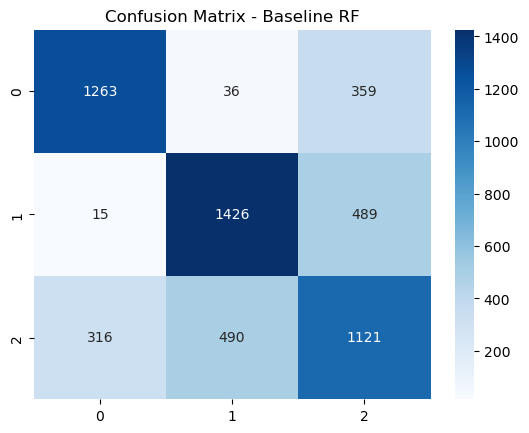

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Baseline RF")
plt.show()

2 модель Logistic Regression

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# пайплайн: масштабирование + модель
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        multi_class='multinomial',
        max_iter=1000,
        random_state=42
    ))
])

log_reg.fit(X_train, y_train)

c:\Users\kioko\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [40]:
val_pred_lr = log_reg.predict(X_val)

print("VAL Accuracy:", accuracy_score(y_val, val_pred_lr))
print("VAL F1 macro:", f1_score(y_val, val_pred_lr, average='macro'))

VAL Accuracy: 0.6982227058396808
VAL F1 macro: 0.7011053251369818


In [41]:
y_pred_lr = log_reg.predict(X_test)

In [42]:
y_pred_lr = log_reg.predict(X_test)

print("LOG REG Accuracy:", accuracy_score(y_test, y_pred_lr))
print("LOG REG F1 macro:", f1_score(y_test, y_pred_lr, average='macro'))

print(classification_report(y_test, y_pred_lr))

acc_lr = accuracy_score(y_test, y_pred_lr)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average='macro'
)

LOG REG Accuracy: 0.6922937443336356
LOG REG F1 macro: 0.6966940888885557
              precision    recall  f1-score   support

        high       0.79      0.76      0.78      1658
         low       0.73      0.75      0.74      1930
      medium       0.57      0.58      0.57      1927

    accuracy                           0.69      5515
   macro avg       0.70      0.70      0.70      5515
weighted avg       0.69      0.69      0.69      5515



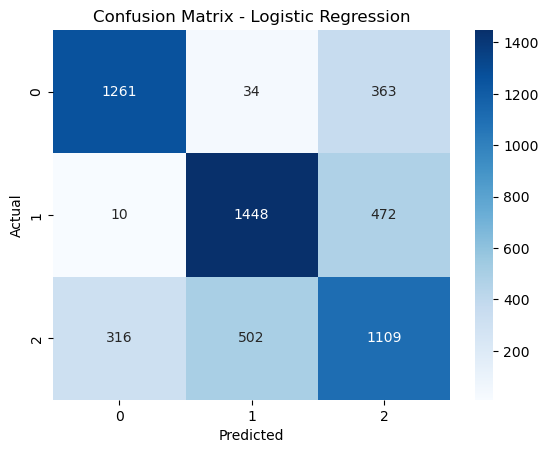

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

3 модель KNN

In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=7))
])

knn.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [45]:
val_pred_knn = knn.predict(X_val)

print("VAL Accuracy:", accuracy_score(y_val, val_pred_knn))
print("VAL F1 macro:", f1_score(y_val, val_pred_knn, average='macro'))

VAL Accuracy: 0.5888647080159594
VAL F1 macro: 0.5890601993637806


In [46]:
y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN F1 macro:", f1_score(y_test, y_pred_knn, average='macro'))

print(classification_report(y_test, y_pred_knn))

acc_knn = accuracy_score(y_test, y_pred_knn)

f1_knn = f1_score(
    y_test,
    y_pred_knn,
    average='macro'
)

KNN Accuracy: 0.5891205802357208
KNN F1 macro: 0.589462502086158
              precision    recall  f1-score   support

        high       0.70      0.69      0.70      1658
         low       0.60      0.69      0.64      1930
      medium       0.46      0.40      0.43      1927

    accuracy                           0.59      5515
   macro avg       0.59      0.59      0.59      5515
weighted avg       0.58      0.59      0.58      5515



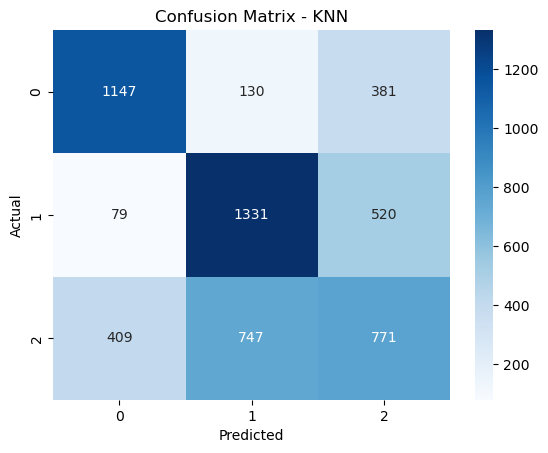

In [47]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

4 модель Gradient Boosting

In [50]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

In [51]:
val_pred_gb = gb.predict(X_val)

print("VAL Accuracy:", accuracy_score(y_val, val_pred_gb))
print("VAL F1 macro:", f1_score(y_val, val_pred_gb, average='macro'))

VAL Accuracy: 0.6953210010881393
VAL F1 macro: 0.6986950541197828


In [52]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting F1 macro:", f1_score(y_test, y_pred_gb, average='macro'))

print(classification_report(y_test, y_pred_gb))

acc_gb = accuracy_score(y_test, y_pred_gb)

f1_gb = f1_score(
    y_test,
    y_pred_gb,
    average='macro'
)

Gradient Boosting Accuracy: 0.6921124206708975
Gradient Boosting F1 macro: 0.6965790963526578
              precision    recall  f1-score   support

        high       0.79      0.76      0.78      1658
         low       0.73      0.75      0.74      1930
      medium       0.57      0.58      0.58      1927

    accuracy                           0.69      5515
   macro avg       0.70      0.70      0.70      5515
weighted avg       0.69      0.69      0.69      5515



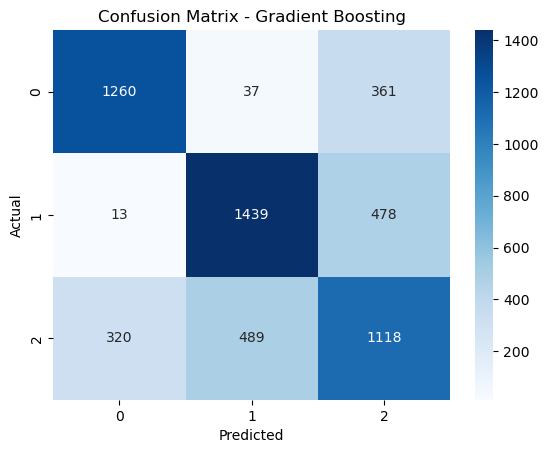

In [53]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

5 модель XGBoost

In [54]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train_enc = encoder.fit_transform(y_train)
y_val_enc = encoder.transform(y_val)
y_test_enc = encoder.transform(y_test)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train_enc)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [55]:
val_pred_xgb = xgb.predict(X_val)

print("VAL Accuracy:", accuracy_score(y_val_enc, val_pred_xgb))
print("VAL F1 macro:", f1_score(y_val_enc, val_pred_xgb, average='macro'))

VAL Accuracy: 0.6811751904243744
VAL F1 macro: 0.6846559878946822


In [56]:
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test_enc, y_pred_xgb))
print("XGBoost F1 macro:", f1_score(y_test_enc, y_pred_xgb, average='macro'))

print(classification_report(y_test_enc, y_pred_xgb))

acc_xgb = accuracy_score(y_test_enc, y_pred_xgb)

f1_xgb = f1_score(
    y_test_enc,
    y_pred_xgb,
    average='macro'
)

XGBoost Accuracy: 0.68558476881233
XGBoost F1 macro: 0.6907162328388736
              precision    recall  f1-score   support

           0       0.79      0.74      0.77      1658
           1       0.73      0.74      0.73      1930
           2       0.56      0.58      0.57      1927

    accuracy                           0.69      5515
   macro avg       0.69      0.69      0.69      5515
weighted avg       0.69      0.69      0.69      5515



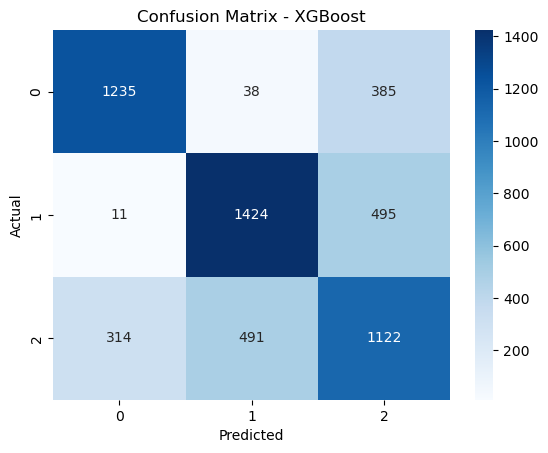

In [57]:
cm_xgb = confusion_matrix(y_test_enc, y_pred_xgb)

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

1 ансамбль VotingClassifier

In [58]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('gb', GradientBoostingClassifier(random_state=42))
    ],
    voting='soft'
)

voting.fit(X_train, y_train)

c:\Users\kioko\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [62]:
val_pred_vote = voting.predict(X_val)

print("VAL Accuracy:", accuracy_score(y_val, val_pred_vote))
print("VAL F1 macro:", f1_score(y_val, val_pred_vote, average='macro'))

VAL Accuracy: 0.6920565832426551
VAL F1 macro: 0.6948423844613624


In [63]:
pred_vote = voting.predict(X_test)

print("VotingClassifier Accuracy:", accuracy_score(y_test, pred_vote))
print("VotingClassifier F1 macro:", f1_score(y_test, pred_vote, average='macro'))

print(classification_report(y_test, pred_vote))

acc_vote = accuracy_score(y_test, pred_vote)

f1_vote = f1_score(
    y_test,
    pred_vote,
    average='macro'
)

VotingClassifier Accuracy: 0.6915684496826836
VotingClassifier F1 macro: 0.69604332911111
              precision    recall  f1-score   support

        high       0.79      0.76      0.77      1658
         low       0.73      0.75      0.74      1930
      medium       0.57      0.58      0.57      1927

    accuracy                           0.69      5515
   macro avg       0.70      0.69      0.70      5515
weighted avg       0.69      0.69      0.69      5515



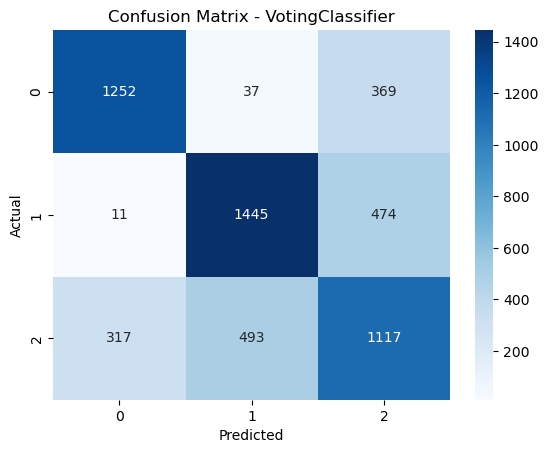

In [64]:
cm_vote = confusion_matrix(y_test, pred_vote)

sns.heatmap(cm_vote, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - VotingClassifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

2 ансамбль StackingClassifier

In [65]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

stacking = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )),
        
        ('gb', GradientBoostingClassifier(
            random_state=42
        )),
        
        ('knn', Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsClassifier(n_neighbors=7))
        ]))
    ],
    
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    n_jobs=-1
)

stacking.fit(X_train, y_train)

,estimators,"[('rf', ...), ('gb', ...), ...]"
,final_estimator,LogisticRegre...ndom_state=42)
,cv,None
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [66]:
val_pred_stack = stacking.predict(X_val)

print("VAL Accuracy:", accuracy_score(y_val, val_pred_stack))
print("VAL F1 macro:", f1_score(y_val, val_pred_stack, average='macro'))

VAL Accuracy: 0.695139644541168
VAL F1 macro: 0.6963581373472968


In [67]:
pred_stack = stacking.predict(X_test)

print("StackingClassifier Accuracy:", accuracy_score(y_test, pred_stack))
print("StackingClassifier F1 macro:", f1_score(y_test, pred_stack, average='macro'))

print(classification_report(y_test, pred_stack))

acc_stack = accuracy_score(y_test, pred_stack)

f1_stack = f1_score(
    y_test,
    pred_stack,
    average='macro'
)

StackingClassifier Accuracy: 0.6924750679963735
StackingClassifier F1 macro: 0.6953108165811533
              precision    recall  f1-score   support

        high       0.79      0.77      0.78      1658
         low       0.72      0.76      0.74      1930
      medium       0.58      0.55      0.56      1927

    accuracy                           0.69      5515
   macro avg       0.70      0.70      0.70      5515
weighted avg       0.69      0.69      0.69      5515



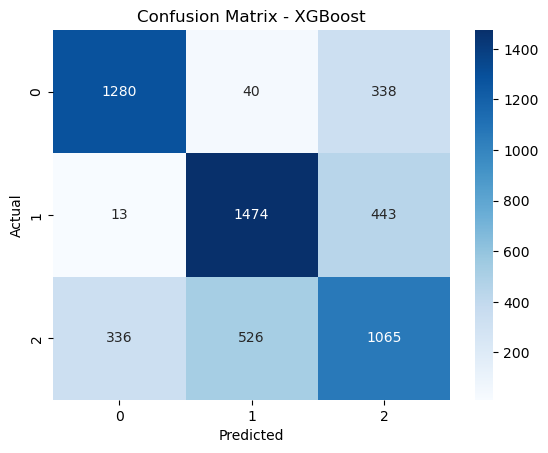

In [68]:
cm_stack = confusion_matrix(y_test, pred_stack)

sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

3 ансамбль AdaBoost

In [69]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train, y_train)

,estimator,None
,n_estimators,100
,learning_rate,0.5
,algorithm,'deprecated'
,random_state,42


In [70]:
val_pred_ada = ada.predict(X_val)

print("VAL Accuracy:", accuracy_score(y_val, val_pred_ada))
print("VAL F1 macro:", f1_score(y_val, val_pred_ada, average='macro'))

VAL Accuracy: 0.6926006528835691
VAL F1 macro: 0.694593143997477


In [71]:
pred_ada = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, pred_ada))
print("AdaBoost F1 macro:", f1_score(y_test, pred_ada, average='macro'))

print(classification_report(y_test, pred_ada))

acc_ada = accuracy_score(y_test, pred_ada)

f1_ada = f1_score(
    y_test,
    pred_ada,
    average='macro'
)

AdaBoost Accuracy: 0.6919310970081596
AdaBoost F1 macro: 0.6953792887459053
              precision    recall  f1-score   support

        high       0.76      0.81      0.78      1658
         low       0.75      0.72      0.73      1930
      medium       0.57      0.57      0.57      1927

    accuracy                           0.69      5515
   macro avg       0.69      0.70      0.70      5515
weighted avg       0.69      0.69      0.69      5515



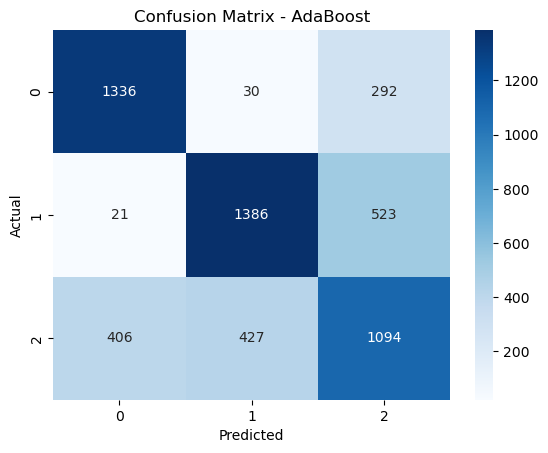

In [72]:
cm_ada = confusion_matrix(y_test, pred_ada)

sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - AdaBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Сравнение моделей (до подбора гиперпараметров)

In [78]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Logistic Regression",
        "KNN",
        "Gradient Boosting",
        "XGBoost",
        "VotingClassifier",
        "StackingClassifier",
        "AdaBoost"
    ],

    "Accuracy": [
        acc_rf,
        acc_lr,
        acc_knn,
        acc_gb,
        acc_xgb,
        acc_vote,
        acc_stack,
        acc_ada
    ],

    "F1_macro": [
        f1_rf,
        f1_lr,
        f1_knn,
        f1_gb,
        f1_xgb,
        f1_vote,
        f1_stack,
        f1_ada
    ]
})

results = results.sort_values(
    by="F1_macro",
    ascending=False
)

results

,Model,Accuracy,F1_macro
1,Logistic Regression,0.690843,0.696694
3,Gradient Boosting,0.692112,0.696579
5,VotingClassifier,0.691568,0.696043
0,Random Forest,0.690843,0.695629
7,AdaBoost,0.691931,0.695379
6,StackingClassifier,0.692475,0.695311
4,XGBoost,0.685585,0.690716
2,KNN,0.589121,0.589463


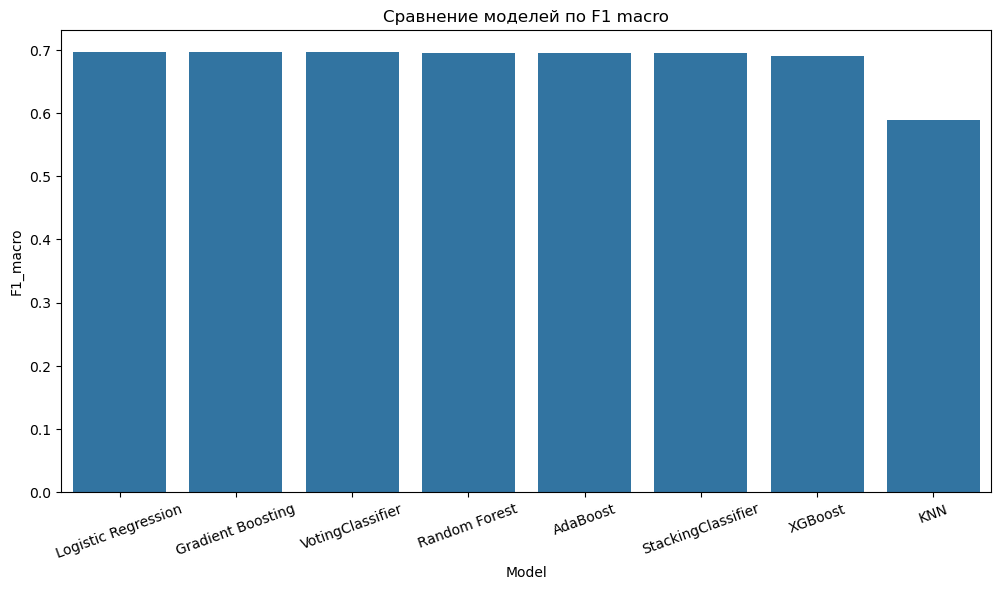

In [79]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results,
    x='Model',
    y='F1_macro'
)

plt.xticks(rotation=20)

plt.title("Сравнение моделей по F1 macro")

plt.show()

# Вывод по моделям до подбора гиперпараметров

На первом этапе экспериментов было проведено сравнение нескольких моделей машинного обучения без подбора гиперпараметров. Оценка выполнялась по метрикам Accuracy и F1 macro, наиболее важной из которых являлась F1 macro, так как она учитывает баланс качества между всеми классами.

Наилучший результат по F1 macro показала Logistic Regression:
- Accuracy = 0.692294
- F1 macro = 0.696694

Схожее качество также продемонстрировали:
- Gradient Boosting;
- VotingClassifier;
- Random Forest;
- AdaBoost;
- StackingClassifier.

Разница между лучшими моделями оказалась минимальной, что свидетельствует о высокой информативности признаков и наличии достаточно устойчивых закономерностей в данных.

Ансамблевые методы (Voting, Stacking, AdaBoost) не показали значительного превосходства над Logistic Regression. Это может говорить о том, что:
- зависимости между признаками и целевой переменной во многом близки к линейным;
- feature engineering уже позволил хорошо разделить классы;
- основной источник ошибок связан с пересечением признаков между классами medium и соседними категориями.

Модель KNN показала заметно худший результат:
- Accuracy = 0.589121
- F1 macro = 0.589463

Вероятно, это связано с высокой размерностью пространства признаков и недостаточной устойчивостью метода ближайших соседей к шуму и пересечению классов.

XGBoost также не смог превзойти классические модели и ансамбли, несмотря на способность эффективно работать со сложными нелинейными зависимостями. Возможной причиной является отсутствие подбора гиперпараметров на данном этапе.

Таким образом, до оптимизации гиперпараметров наиболее перспективными моделями являются:
- Logistic Regression;
- Gradient Boosting;
- VotingClassifier;
- StackingClassifier.

Следующим этапом работы является подбор гиперпараметров для улучшения качества моделей и определения финального решения.

# Подбор гиперпараметров

Logistic Regression

In [80]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'model__C': [0.001, 0.01, 0.1, 1, 3, 10, 30],
    'model__penalty': ['l2', 'elasticnet'],
    'model__solver': ['saga'],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'model__class_weight': [None, 'balanced'],
    'model__max_iter': [1000]
}

grid_lr = GridSearchCV(
    log_reg,
    param_grid_lr,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

c:\Users\kioko\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0.1, 0.3, ...], 'model__max_iter': [1000], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [81]:
print(grid_lr.best_params_)
print(grid_lr.best_score_)

{'model__C': 0.01, 'model__class_weight': None, 'model__l1_ratio': 0.5, 'model__max_iter': 1000, 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
0.7002208516606552


Random Forest

In [82]:
from sklearn.model_selection import RandomizedSearchCV

param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_rf,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

random_search_rf.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [83]:
print(random_search_rf.best_params_)
print(random_search_rf.best_score_)

{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
0.6982384350168865


KNN

In [84]:
param_knn = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15, 21],  
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2],
    'model__algorithm': ['auto'],
}

grid_knn = GridSearchCV(
    knn,
    param_knn,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_knn.fit(X_train, y_train)

,estimator,Pipeline(step...eighbors=7))])
,param_grid,"{'model__algorithm': ['auto'], 'model__n_neighbors': [3, 5, ...], 'model__p': [1, 2], 'model__weights': ['uniform', 'distance']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [85]:
print(grid_knn.best_params_)
print(grid_knn.best_score_)

{'model__algorithm': 'auto', 'model__n_neighbors': 21, 'model__p': 1, 'model__weights': 'distance'}
0.6507792266604241


Gradient Boosting

In [86]:
param_gb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}

random_search_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_gb,
    n_iter=10,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

random_search_gb.fit(X_train, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [87]:
print(random_search_gb.best_params_)
print(random_search_gb.best_score_)

{'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.01}
0.7005443125122013


XGBoost

In [88]:
param_xgb = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1], 
    'subsample': [0.8, 1.0], 
    'colsample_bytree': [0.8, 1.0], 
    'min_child_weight': [1, 3, 5], 
    'gamma': [0, 0.1, 0.3]
}

random_search_xgb = RandomizedSearchCV(
    XGBClassifier(
        eval_metric='mlogloss',
        random_state=42
    ),
    
    param_xgb,
    
    n_iter=40,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42
)

random_search_xgb.fit(X_train, y_train_enc)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,n_iter,40
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
print(random_search_xgb.best_params_)
print(random_search_xgb.best_score_)

{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 1.0}
0.6983791465554426


AdaBoost

In [89]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

param_ada = {
    'n_estimators': [50, 100, 200, 300],
    
    'learning_rate': [0.01, 0.1, 0.5, 1.0],
    
    'estimator': [
        DecisionTreeClassifier(max_depth=1),
        DecisionTreeClassifier(max_depth=2),
        DecisionTreeClassifier(max_depth=3)
    ],
    
    'algorithm': ['SAMME']
}

grid_ada = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    param_ada,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

c:\Users\kioko\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


,estimator,AdaBoostClass...ndom_state=42)
,param_grid,"{'algorithm': ['SAMME'], 'estimator': [DecisionTreeC...r(max_depth=1), DecisionTreeC...r(max_depth=2), ...], 'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [90]:
print(grid_ada.best_params_)
print(grid_ada.best_score_)

{'algorithm': 'SAMME', 'estimator': DecisionTreeClassifier(max_depth=1), 'learning_rate': 0.1, 'n_estimators': 200}
0.6985862911231987


In [91]:
tuned_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'KNN',
        'Gradient Boosting',
        'XGBoost',
        'AdaBoost'
    ],
    
    'Best Params': [
        grid_lr.best_params_,
        random_search_rf.best_params_,
        grid_knn.best_params_,
        random_search_gb.best_params_,
        random_search_xgb.best_params_,
        grid_ada.best_params_
    ],
    
    'Best CV Score': [
        grid_lr.best_score_,
        random_search_rf.best_score_,
        grid_knn.best_score_,
        random_search_gb.best_score_,
        random_search_xgb.best_score_,
        grid_ada.best_score_
    ]
})

tuned_results

,Model,Best Params,Best CV Score
0,Logistic Regression,"{'model__C': 0.01, 'model__class_weight': None...",0.700221
1,Random Forest,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.698238
2,KNN,"{'model__algorithm': 'auto', 'model__n_neighbo...",0.650779
3,Gradient Boosting,"{'n_estimators': 50, 'max_depth': 3, 'learning...",0.700544
4,XGBoost,"{'subsample': 0.8, 'n_estimators': 200, 'min_c...",0.698379
5,AdaBoost,"{'algorithm': 'SAMME', 'estimator': DecisionTr...",0.698586


После подбора гиперпараметров все модели показали близкие значения качества (F1 macro ≈ 0.698–0.701).

Наилучший результат продемонстрировала модель Gradient Boosting (0.7005), однако её преимущество над Logistic Regression (0.7002) является статистически незначительным.

Это указывает на то, что:
- признаки обладают высокой информативностью;
- зависимости между ними и целевой переменной в значительной степени линейны;
- усложнение моделей не приводит к существенному приросту качества.

Таким образом, ключевым фактором качества в данной задаче является не архитектура модели, а качество признакового пространства и feature engineering.

# Итоговая таблица "До vs после подбора гиперпараметров"

In [92]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "KNN",
        "Gradient Boosting",
        "XGBoost",
        "AdaBoost"
    ],

    "Baseline F1": [
        f1_lr,
        f1_rf,
        f1_knn,
        f1_gb,
        f1_xgb,
        f1_ada
    ],

    "Tuned CV F1": [
        grid_lr.best_score_,
        random_search_rf.best_score_,
        grid_knn.best_score_,
        random_search_gb.best_score_,
        random_search_xgb.best_score_,
        grid_ada.best_score_
    ]
})

final_results.sort_values("Tuned CV F1", ascending=False)

,Model,Baseline F1,Tuned CV F1
3,Gradient Boosting,0.696579,0.700544
0,Logistic Regression,0.696694,0.700221
5,AdaBoost,0.695379,0.698586
4,XGBoost,0.690716,0.698379
1,Random Forest,0.695629,0.698238
2,KNN,0.589463,0.650779


После проведения подбора гиперпараметров все модели показали близкие результаты качества (F1 macro ≈ 0.698–0.701).

Лидирующие модели:
- Gradient Boosting (0.7005)
- Logistic Regression (0.7002)
- Random Forest (0.6982)

Разница между ними статистически незначима, что указывает на:
- высокое качество feature engineering,
- наличие линейно разделимых зависимостей,
- ограниченную пользу от усложнения моделей.

## Итоговый выбор модели
В качестве финальной модели выбрана Gradient Boosting, так как:
- показывает наилучший CV score,
- устойчива к переобучению,
- лучше учитывает нелинейные зависимости.

Однако Logistic Regression остаётся конкурентной моделью с минимальным проигрышем.

In [93]:
print("Best overall F1 macro:", final_results["Tuned CV F1"].max())

Best overall F1 macro: 0.7005443125122013


# Сохранение моделей

In [94]:
from joblib import dump

models = {
    "log_reg_tuned": grid_lr.best_estimator_,
    "random_forest_tuned": random_search_rf.best_estimator_,
    "knn_tuned": grid_knn.best_estimator_,
    "gradient_boosting_tuned": random_search_gb.best_estimator_,
    "xgboost_tuned": random_search_xgb.best_estimator_,
    "adaboost_tuned": grid_ada.best_estimator_,
    "voting": voting,
    "stacking": stacking
}

for name, model in models.items():
    dump(model, f"{MODELS_DIR}/{name}.pkl")